In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [30]:
import os

BASE_DIR = "/kaggle/working/CliniScan-Lung-Abnormality"

folders = [
    "scripts",
    "docs",
    "notebooks"
]

for folder in folders:
    os.makedirs(os.path.join(BASE_DIR, folder), exist_ok=True)

print("Project folders created")

Project folders created


In [5]:
import os

DATASET_PATH = "/kaggle/input/vinbigdata-chest-xray-abnormalities-detection"
print(os.listdir(DATASET_PATH))

['sample_submission.csv', 'train.csv', 'test', 'train']


In [6]:
import os
import numpy as np
import pandas as pd
import cv2
import pydicom
import matplotlib.pyplot as plt
from tqdm import tqdm

In [7]:
DATASET_PATH = "/kaggle/input/vinbigdata-chest-xray-abnormalities-detection"
print(os.listdir(DATASET_PATH))

['sample_submission.csv', 'train.csv', 'test', 'train']


In [8]:
DICOM_DIR = os.path.join(DATASET_PATH, "train")
dicom_files = os.listdir(DICOM_DIR)

print("Total DICOM images:", len(dicom_files))
print("Sample files:", dicom_files[:5])

Total DICOM images: 15000
Sample files: ['4d390e07733ba06e5ff07412f09c0a92.dicom', '289f69f6462af4933308c275d07060f0.dicom', '68335ee73e67706aa59b8b55b54b11a4.dicom', '7ecd6f67f649f26c05805c8359f9e528.dicom', '2229148faa205e881cf0d932755c9e40.dicom']


In [9]:
train_df = pd.read_csv(os.path.join(DATASET_PATH, "train.csv"))
train_df.head()

,image_id,class_name,class_id,rad_id,x_min,y_min,x_max,y_max
0,50a418190bc3fb1ef1633bf9678929b3,No finding,14,R11,NaN,NaN,NaN,NaN
1,21a10246a5ec7af151081d0cd6d65dc9,No finding,14,R7,NaN,NaN,NaN,NaN
2,9a5094b2563a1ef3ff50dc5c7ff71345,Cardiomegaly,3,R10,691.0,1375.0,1653.0,1831.0
3,051132a778e61a86eb147c7c6f564dfe,Aortic enlargement,0,R10,1264.0,743.0,1611.0,1019.0
4,063319de25ce7edb9b1c6b8881290140,No finding,14,R10,NaN,NaN,NaN,NaN


In [10]:
SUBSET_SIZE = 300  # start small
subset_images = dicom_files[:SUBSET_SIZE]

print("Using images:", len(subset_images))

Using images: 300


In [11]:
subset_ids = [f.replace(".dicom", "") for f in subset_images]

subset_df = train_df[train_df["image_id"].isin(subset_ids)]
print("Subset annotations:", subset_df.shape)

Subset annotations: (1447, 8)


(np.float64(-0.5), np.float64(2999.5), np.float64(2999.5), np.float64(-0.5))

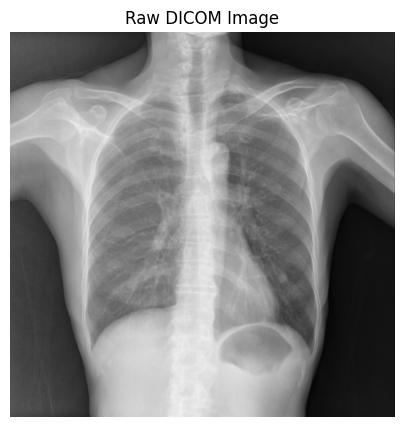

In [12]:
sample_dicom = os.path.join(DICOM_DIR, subset_images[0])
ds = pydicom.dcmread(sample_dicom)
img = ds.pixel_array

plt.figure(figsize=(5,5))
plt.imshow(img, cmap="gray")
plt.title("Raw DICOM Image")
plt.axis("off")

In [14]:
PNG_DIR = "/kaggle/working/png_images"
os.makedirs(PNG_DIR, exist_ok=True)

In [20]:
def dicom_to_png(dicom_path, save_path):
    ds = pydicom.dcmread(dicom_path)
    img = ds.pixel_array.astype(np.float32)

    # Min-Max normalization
    img = (img - img.min()) / (img.max() - img.min())
    img = (img * 255).astype(np.uint8)

    cv2.imwrite(save_path, img)

In [21]:
for file in tqdm(subset_images):
    dicom_path = os.path.join(DICOM_DIR, file)
    png_path = os.path.join(PNG_DIR, file.replace(".dicom", ".png"))
    dicom_to_png(dicom_path, png_path)

100%|██████████| 300/300 [07:15<00:00,  1.45s/it]


(np.float64(-0.5), np.float64(2673.5), np.float64(3246.5), np.float64(-0.5))

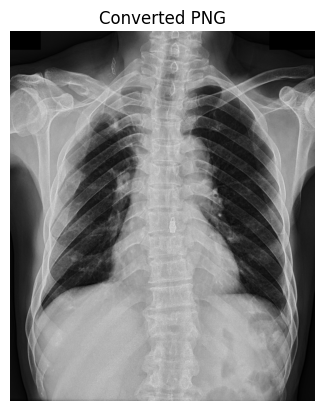

In [22]:
sample_png = os.listdir(PNG_DIR)[0]
img = cv2.imread(os.path.join(PNG_DIR, sample_png), cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap="gray")
plt.title("Converted PNG")
plt.axis("off")

In [25]:
def preprocess_image(img, target_size=(512, 512)):
    # Resize
    img = cv2.resize(img, target_size)

    # Intensity normalization
    img = (img - img.min()) / (img.max() - img.min())
    img = (img * 255).astype(np.uint8)

    # CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)

    # Denoising
    img = cv2.GaussianBlur(img, (3,3), 0)

    return img

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

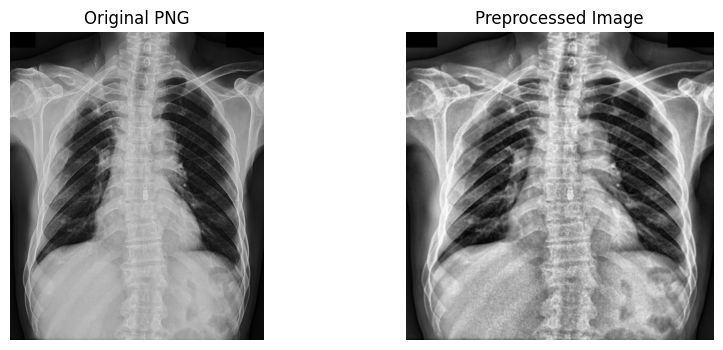

In [26]:
processed = preprocess_image(img)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img, cmap="gray")
plt.title("Original PNG")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(processed, cmap="gray")
plt.title("Preprocessed Image")
plt.axis("off")

In [27]:
PREPROCESSED_DIR = "/kaggle/working/preprocessed"
os.makedirs(PREPROCESSED_DIR, exist_ok=True)

for file in tqdm(os.listdir(PNG_DIR)):
    img = cv2.imread(os.path.join(PNG_DIR, file), cv2.IMREAD_GRAYSCALE)
    img = preprocess_image(img)
    cv2.imwrite(os.path.join(PREPROCESSED_DIR, file), img)

100%|██████████| 300/300 [00:28<00:00, 10.61it/s]


In [29]:
LABEL_DIR = "/kaggle/working/labels"
os.makedirs(LABEL_DIR, exist_ok=True)

for image_id, group in subset_df.groupby("image_id"):
    label_path = os.path.join(LABEL_DIR, image_id + ".txt")

    with open(label_path, "w") as f:
        for _, row in group.iterrows():
            if row["class_id"] == 14:
                continue

            x_center = (row.x_min + row.x_max) / 2
            y_center = (row.y_min + row.y_max) / 2
            width = row.x_max - row.x_min
            height = row.y_max - row.y_min

            f.write(f"{row.class_id} {x_center} {y_center} {width} {height}\n")

In [31]:
dicom_code = """
import os
import cv2
import pydicom
import numpy as np
from tqdm import tqdm

DICOM_DIR = "/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/train"
OUTPUT_DIR = "data/png_images"

os.makedirs(OUTPUT_DIR, exist_ok=True)

def dicom_to_png(dicom_path, save_path):
    ds = pydicom.dcmread(dicom_path)
    img = ds.pixel_array.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min())
    img = (img * 255).astype(np.uint8)
    cv2.imwrite(save_path, img)

def main():
    files = os.listdir(DICOM_DIR)[:300]
    for file in tqdm(files):
        dicom_to_png(
            os.path.join(DICOM_DIR, file),
            os.path.join(OUTPUT_DIR, file.replace(".dicom", ".png"))
        )

if __name__ == "__main__":
    main()
"""

with open(f"{BASE_DIR}/scripts/dicom_to_png.py", "w") as f:
    f.write(dicom_code)

print("dicom_to_png.py created")

dicom_to_png.py created


In [32]:
preprocessing_code = """
import cv2
import os
import numpy as np
from tqdm import tqdm

INPUT_DIR = "data/png_images"
OUTPUT_DIR = "data/preprocessed"

os.makedirs(OUTPUT_DIR, exist_ok=True)

def preprocess_image(img, target_size=(512, 512)):
    img = cv2.resize(img, target_size)
    img = (img - img.min()) / (img.max() - img.min())
    img = (img * 255).astype(np.uint8)
    clahe = cv2.createCLAHE(2.0, (8,8))
    img = clahe.apply(img)
    img = cv2.GaussianBlur(img, (3,3), 0)
    return img

def main():
    for file in tqdm(os.listdir(INPUT_DIR)):
        img = cv2.imread(os.path.join(INPUT_DIR, file), cv2.IMREAD_GRAYSCALE)
        img = preprocess_image(img)
        cv2.imwrite(os.path.join(OUTPUT_DIR, file), img)

if __name__ == "__main__":
    main()
"""

with open(f"{BASE_DIR}/scripts/preprocessing.py", "w") as f:
    f.write(preprocessing_code)

print("preprocessing.py created")

preprocessing.py created


In [33]:
annotation_code = """
import pandas as pd
import os

CSV_PATH = "/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/train.csv"
LABEL_DIR = "data/labels"

os.makedirs(LABEL_DIR, exist_ok=True)

def main():
    df = pd.read_csv(CSV_PATH)
    image_ids = df["image_id"].unique()[:300]
    df = df[df["image_id"].isin(image_ids)]

    for image_id, group in df.groupby("image_id"):
        with open(os.path.join(LABEL_DIR, image_id + ".txt"), "w") as f:
            for _, row in group.iterrows():
                if row["class_id"] == 14:
                    continue
                x_center = (row.x_min + row.x_max) / 2
                y_center = (row.y_min + row.y_max) / 2
                w = row.x_max - row.x_min
                h = row.y_max - row.y_min
                f.write(f"{row.class_id} {x_center} {y_center} {w} {h}\\n")

if __name__ == "__main__":
    main()
"""

with open(f"{BASE_DIR}/scripts/annotation_conversion.py", "w") as f:
    f.write(annotation_code)

print("annotation_conversion.py created")

annotation_conversion.py created


In [34]:
readme_text = """
# CliniScan: Lung Abnormality Detection on Chest X-rays

## Overview
AI-based system for detecting and localizing lung abnormalities in chest X-ray images.

## Milestone 1
- DICOM to PNG conversion
- Image preprocessing
- Annotation conversion (YOLO format)

## Dataset
VinBigData Chest X-ray Abnormalities Detection (Kaggle)

## Note
Dataset files are not included in this repository.
"""

with open(f"{BASE_DIR}/README.md", "w") as f:
    f.write(readme_text)

print("README.md created")

README.md created


In [35]:
gitignore_text = """
data/
*.dicom
*.png
__pycache__/
.ipynb_checkpoints/
.DS_Store
"""

with open(f"{BASE_DIR}/.gitignore", "w") as f:
    f.write(gitignore_text)

print(".gitignore created")

.gitignore created


In [36]:
!zip -r CliniScan-Lung-Abnormality.zip /kaggle/working/CliniScan-Lung-Abnormality

  adding: kaggle/working/CliniScan-Lung-Abnormality/ (stored 0%)
  adding: kaggle/working/CliniScan-Lung-Abnormality/.gitignore (deflated 3%)
  adding: kaggle/working/CliniScan-Lung-Abnormality/docs/ (stored 0%)
  adding: kaggle/working/CliniScan-Lung-Abnormality/notebooks/ (stored 0%)
  adding: kaggle/working/CliniScan-Lung-Abnormality/README.md (deflated 36%)
  adding: kaggle/working/CliniScan-Lung-Abnormality/scripts/ (stored 0%)
  adding: kaggle/working/CliniScan-Lung-Abnormality/scripts/preprocessing.py (deflated 48%)
  adding: kaggle/working/CliniScan-Lung-Abnormality/scripts/annotation_conversion.py (deflated 49%)
  adding: kaggle/working/CliniScan-Lung-Abnormality/scripts/dicom_to_png.py (deflated 46%)


In [37]:
!ls /kaggle/working

CliniScan-Lung-Abnormality	labels	    preprocessed
CliniScan-Lung-Abnormality.zip	png_images
